In [2]:
%load_ext dotenv
%dotenv /home/aurora/.env
%matplotlib inline

In [3]:
import numpy as np
import pandas as pd
import datetime as dt
from google.cloud import bigquery
import re
import pymongo
import os
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from flatten_json import flatten
#warnings.filterwarnings('ignore')

In [4]:
# Time
start = dt.datetime(2019,4,30)
end = dt.datetime(2019,5,5)
print(start,end,end-start)

2019-04-30 00:00:00 2019-05-05 00:00:00 5 days, 0:00:00


In [5]:
cursor = pymongo.MongoClient("mongodb://" + os.environ['user'] + ':' + 
                             os.environ['pass'] + '@' + os.environ['db1']  + "/?authSource=" + 
                             os.environ['dbname'])
c_users = cursor.superstars.users
aw = []
for documents in c_users.find({'created_at': {'$lt': end, '$gte': start}},{"sign_up_details":1, "created_at":1,"login_details":1}):
    aw.append(documents)
dic_flattened = [flatten(d) for d in aw]
df = pd.DataFrame(dic_flattened)
df = df[df["sign_up_details_app_platform"] == "UNITY_Android"]
#df = df[df["sign_up_details_device_id"].isin(devices)]
users = df[["_id","created_at","sign_up_details_device_height","sign_up_details_device_width","login_details_last_request_at"]]
users.columns = ["user_id","createtime","height","width","last_request"]
users['resolution'] = users['height'].astype(str) +'*'+ users['width'].astype(str)
print(users.head())
print(len(users))

                    user_id              createtime  height  width  \
0  5cc79098304ded1c8d247a15 2019-04-30 00:02:32.274    2160   1080   
1  5cc7986cc757b72b3a1c8681 2019-04-30 00:35:56.652    1440    720   
2  5cc798b6c1811e2b616907ef 2019-04-30 00:37:10.226    1280    720   
3  5cc79982aaefa53d8f9ac785 2019-04-30 00:40:34.006    1440    720   
4  5cc79b24c757b72b3a1c89ec 2019-04-30 00:47:32.593    1280    720   

             last_request resolution  
0 2019-04-30 00:28:40.091  2160*1080  
1 2019-04-30 00:59:47.981   1440*720  
2 2019-04-30 00:37:36.007   1280*720  
3 2019-04-30 07:50:23.633   1440*720  
4 2019-04-30 07:54:20.873   1280*720  
662


/home/aurora/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


In [6]:
team_cursor = cursor.superstars.teams
aw = []
for documents in team_cursor.find({'created_at': {'$gte': start}}):
    aw.append(documents)
dic_flattened = [flatten(d) for d in aw]
df = pd.DataFrame(dic_flattened)
df.head()
teams = df[df["user"].isin(users["user_id"])]
teams = teams[["_id","user","entry_league"]]
teams.columns = ["team_id", "user_id", "entry league"]
teams.head()
print(len(teams))

658


In [7]:
dm = pd.merge(users,teams,on='user_id',how='inner')
dm.head()

,user_id,createtime,height,width,last_request,resolution,team_id,entry league
0,5cc79098304ded1c8d247a15,2019-04-30 00:02:32.274,2160,1080,2019-04-30 00:28:40.091,2160*1080,5cc79098304ded1c8d247a1d,NaN
1,5cc7986cc757b72b3a1c8681,2019-04-30 00:35:56.652,1440,720,2019-04-30 00:59:47.981,1440*720,5cc7986cc757b72b3a1c8689,NaN
2,5cc798b6c1811e2b616907ef,2019-04-30 00:37:10.226,1280,720,2019-04-30 00:37:36.007,1280*720,5cc798b6c1811e2b616907f7,NaN
3,5cc79982aaefa53d8f9ac785,2019-04-30 00:40:34.006,1440,720,2019-04-30 07:50:23.633,1440*720,5cc79982aaefa53d8f9ac78d,NaN
4,5cc79b24c757b72b3a1c89ec,2019-04-30 00:47:32.593,1280,720,2019-04-30 07:54:20.873,1280*720,5cc79b24c757b72b3a1c89f4,NaN


In [8]:
dm['d1'] = (dm['last_request']-dm['createtime'])>'24:00:00'
dm['d3'] = (dm['last_request']-dm['createtime'])>'72:00:00'
dm['d7'] = (dm['last_request']-dm['createtime'])>'168:00:00'
dm.head()

,user_id,createtime,height,width,last_request,resolution,team_id,entry league,d1,d3,d7
0,5cc79098304ded1c8d247a15,2019-04-30 00:02:32.274,2160,1080,2019-04-30 00:28:40.091,2160*1080,5cc79098304ded1c8d247a1d,NaN,False,False,False
1,5cc7986cc757b72b3a1c8681,2019-04-30 00:35:56.652,1440,720,2019-04-30 00:59:47.981,1440*720,5cc7986cc757b72b3a1c8689,NaN,False,False,False
2,5cc798b6c1811e2b616907ef,2019-04-30 00:37:10.226,1280,720,2019-04-30 00:37:36.007,1280*720,5cc798b6c1811e2b616907f7,NaN,False,False,False
3,5cc79982aaefa53d8f9ac785,2019-04-30 00:40:34.006,1440,720,2019-04-30 07:50:23.633,1440*720,5cc79982aaefa53d8f9ac78d,NaN,False,False,False
4,5cc79b24c757b72b3a1c89ec,2019-04-30 00:47:32.593,1280,720,2019-04-30 07:54:20.873,1280*720,5cc79b24c757b72b3a1c89f4,NaN,False,False,False


In [9]:
f = {'user_id':'count','entry league':'count','d1':'sum','d3':'sum','d7':'sum'}
a = dm.groupby('resolution').agg(f)
a.sort_values('user_id',ascending=False,inplace=True)
a.head()
a['entry league'] = a['entry league']/a['user_id']
a['d1'] = a['d1']/a['user_id']
a['d3'] = a['d3']/a['user_id']
a['d7'] = a['d7']/a['user_id']
a[['entry league','d1','d3','d7']] = (a[['entry league','d1','d3','d7']]*100).round()
a.rename(columns={'user_id':'no of users','entry league':'league joined %','d1':'d1 %','d3':'d3 %','d7':'d7 %'}, inplace=True)
a.head()

,no of users,league joined %,d1 %,d3 %,d7 %
resolution,,,,,
1280*720,250,6.0,29.0,18.0,10.0
1920*1080,89,16.0,36.0,27.0,15.0
1440*720,88,7.0,31.0,25.0,11.0
2160*1080,58,9.0,29.0,19.0,7.0
1440*810,20,0.0,5.0,0.0,0.0


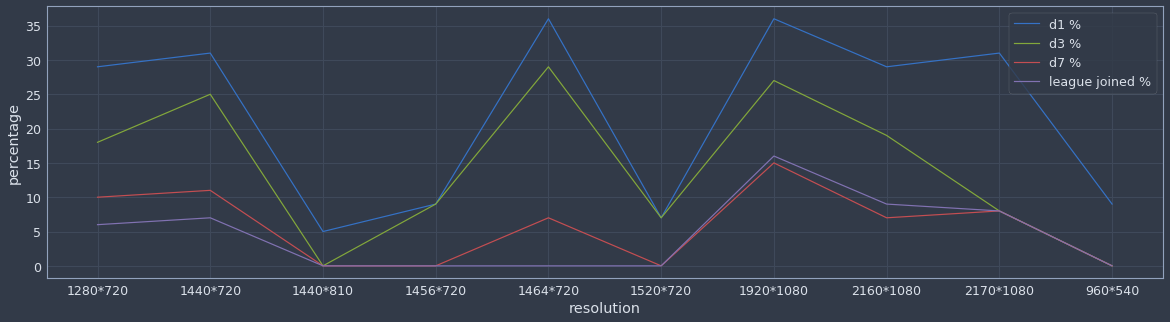

In [11]:
fig, axs = plt.subplots(figsize = (20, 5))

b = a[0:10]
b = b.reset_index()
sns.lineplot(x="resolution", y='d1 %',  data=b, ax = axs,label='d1 %')
sns.lineplot(x="resolution", y='d3 %',  data=b, ax = axs,label = 'd3 %')
sns.lineplot(x="resolution", y='d7 %',  data=b, ax = axs,label = 'd7 %')
sns.lineplot(x="resolution", y='league joined %',  data=b, ax = axs, label = 'league joined %')
axs.set_ylabel('percentage')
#axs.set_ylabel('percentage')
plt.show()